
This notebook mainly does 4 things:
1. Read in data and convert it into a graph
2. Clean up and complete the graph
3. Save the graph as jsons (as needed for generating plans)
4. Generate plans

Two main variables/output of note:

- bg_graph: A "gerrychain" graph, built from networkx graphs and follows all networkx functions/syntax. Each node represents a block group and contains all info on block group (see second python shell below). The cleaned up/completed graph is saved as ca_districtr_bg_view_v1.json in the same directory. If you need to generate this again, remember to run everything under "Connect islands and disconnected components"; otherwise the graph is not complete.
- Output from chain: 1000 plans each for [8, 10, 16, 20, 40, 80] districts, separately saved in jsons in districting/chain_out. Each plan is essentially a vector of length len(bg_graph.nodes())==[number of block groups], where ith entry corresponds to district assignment (as ints) for ith (0-indexed) block group, corresponding to ith node in bg_graph. If I don't get to it, you might have to aggregate info acrpss nodes by district assignment.

Data is in dropbox link on email. All results generated from this notebook are in the districting folder and were committed to github.

## Read data, convert to json
Gerrychain takes json as input. The (geopandas) geopackage read from dataset should be converted first to graph. We need to edit the graph so that there are no disconnected nodes, and then the complete graph is converted to a json. We use data on the census block group level.

In [1]:
import geopandas as gpd
import fiona
from pathlib import Path
from gerrychain import Graph


# Read in geopackage
# CA_data == entire folder from Peter
gpkg = Path("../CA_data/ca_districtr_bg_view_v1.gpkg")
layers = fiona.listlayers(gpkg)

# You should see a layer that says something like "ca_districtr_county_view_v1"
print(layers)

# Read in geopackage
gdf = gpd.read_file(gpkg, layer="ca_districtr_bg_view_v1")

# Add coordinates for plotting
gdf['C_X'] = gdf.centroid.x
gdf['C_Y'] = gdf.centroid.y
print(gdf.head())

# Convert geopackage first into a gpd graph
bg_graph = Graph.from_geodataframe(gdf)

# Check number of nodes (block groups)
print(len(bg_graph.nodes()))

['ca_districtr_bg_view_v1', 'ca_districtr_bg_view_v1__internal_points', 'gerrydb_view_meta', 'gerrydb_geo_meta', 'gerrydb_geo_attrs', 'gerrydb_graph_edge']


/var/folders/_6/vw90rr_n1k51nrvqcpj93ygr0000gn/T/ipykernel_10905/3713949898.py:19: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['C_X'] = gdf.centroid.x
/var/folders/_6/vw90rr_n1k51nrvqcpj93ygr0000gn/T/ipykernel_10905/3713949898.py:20: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['C_Y'] = gdf.centroid.y


           path  total_pop_20  bpop_20  hpop_20  asian_nhpi_pop_20  \
0  060014001001        1789.0     95.0    125.0              343.0   
1  060014001002        1249.0    116.0     73.0              347.0   
2  060014002001        1022.0     30.0    102.0              132.0   
3  060014002002         979.0     45.0     95.0              168.0   
4  060014003001        1123.0     60.0     74.0              164.0   

   amin_pop_20  other_pop_20  white_pop_20  total_vap_20  bvap_20  ...  \
0         13.0          56.0        1157.0        1540.0     74.0  ...   
1          6.0          24.0         683.0        1093.0     94.0  ...   
2         12.0          24.0         722.0         832.0     17.0  ...   
3          0.0          10.0         661.0         820.0     37.0  ...   
4          7.0          16.0         802.0         914.0     48.0  ...   

   pres_16_rep  gov_18_dem  gov_18_rep  ag_18_dem  ag_18_rep  pres_20_dem  \
0         85.0       944.0       122.0      935.0      11

/Users/hanelee/miniconda3/envs/redistrict/lib/python3.13/site-packages/gerrychain/graph/graph.py:406: UserWarning: Found islands (degree-0 nodes). Indices of islands: {20398, 9431}
  warnings.warn(


25607


/Users/hanelee/miniconda3/envs/redistrict/lib/python3.13/site-packages/gerrychain/graph/graph.py:266: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  areas = df.geometry.area.to_dict()


In [2]:
# Nodes contain block group info.
# bg_graph is not complete yet.
 
bg_graph.nodes()[0]

{'boundary_node': False,
 'area': 0.000587509117000003,
 'path': '060014001001',
 'total_pop_20': 1789.0,
 'bpop_20': 95.0,
 'hpop_20': 125.0,
 'asian_nhpi_pop_20': 343.0,
 'amin_pop_20': 13.0,
 'other_pop_20': 56.0,
 'white_pop_20': 1157.0,
 'total_vap_20': 1540.0,
 'bvap_20': 74.0,
 'hvap_20': 91.0,
 'asian_nhpi_vap_20': 275.0,
 'amin_vap_20': 12.0,
 'other_vap_20': 40.0,
 'white_vap_20': 1048.0,
 'pres_08_dem': 880.0,
 'pres_08_rep': 168.0,
 'pres_12_dem': 862.0,
 'pres_12_rep': 169.0,
 'pres_16_dem': 1031.0,
 'pres_16_rep': 85.0,
 'gov_18_dem': 944.0,
 'gov_18_rep': 122.0,
 'ag_18_dem': 935.0,
 'ag_18_rep': 119.0,
 'pres_20_dem': 1124.0,
 'pres_20_rep': 122.0,
 'geometry': <POLYGON ((-122.247 37.885, -122.247 37.885, -122.246 37.884, -122.245 37.88...>,
 'C_X': -122.23362098059268,
 'C_Y': 37.869878443094514}

### Visualize the Block Groups

/Users/hanelee/miniconda3/envs/redistrict/lib/python3.13/site-packages/networkx/drawing/nx_pylab.py:1438: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  node_collection = ax.scatter(


<Axes: >

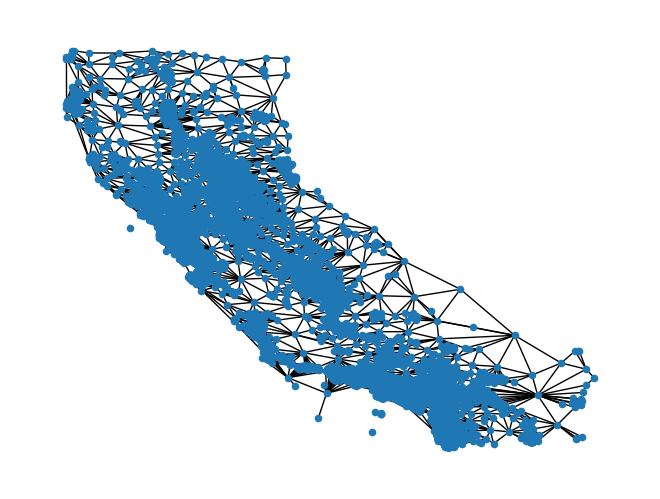

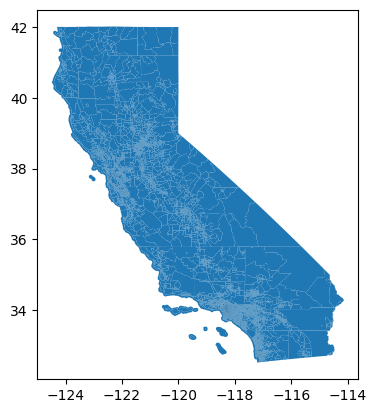

In [17]:
import networkx as nx

# Draws graph with nodes
nx.draw(bg_graph,pos = {x:(bg_graph.nodes[x]['C_X'], bg_graph.nodes[x]['C_Y']) for x in bg_graph.nodes()}, node_size=20, cmap='coolwarm_r')
######node_color=[bg_graph.nodes[x]['P0010003']/(bg_graph.nodes[x]['P0010001']+1) for x in bg_graph.nodes()],

# Draw map
gdf.plot()

## Connect islands and disconnected components
We identify islands and disconnected components in the graph and manually connect them to geographically closest nodes.
Documentation: 
https://github.com/mggg/maup/wiki/What-to-do-about-islands-and-connectivity

In [ ]:
# First check if islands or small graph compnents exist

import networkx as nx

# bg_graph is gpd graph
islands = bg_graph.islands

# print node numbers that are islands
print(islands)

# Look at graph components and the length of each
components = list(nx.connected_components(bg_graph))
print([len(c) for c in components])

set()
[25607]


In [ ]:
# Identify the nodes that are not in largest component, print node numbers, visualize on graph

biggest_component_size = max(len(c) for c in components)
problem_components = [c for c in components if len(c) != biggest_component_size]
problem_nodes = [node for component in problem_components for node in component]
print(problem_nodes)

# Create a color column: red for problem node rows, lightgray otherwise
gdf['color'] = ['red' if i in problem_nodes else 'lightgray' for i in gdf.index]

# Plot with custom colors
gdf.plot(color=gdf['color'])


[]


In [ ]:
# For each problem node, find 5 shapes that have closest coordinates

import geopandas as gpd
import pandas as pd

# Reproject to a CRS with meters as units (if not already)
gdf = gdf.to_crs("EPSG:3857")

# Exclude all highlighted rows from possible neighbors
neighbor_candidates = gdf.drop(index=problem_nodes)

# Dictionary to hold 5 nearest neighbors for each highlighted row
nearest_rows = {}

for i in problem_nodes:
    source_geom = gdf.loc[i].geometry

    # Calculate distances to all non-highlighted rows
    distances = neighbor_candidates.geometry.distance(source_geom)

    # Get the indices of the 5 closest geometries
    nearest_indices = distances.nsmallest(5).index.tolist()

    nearest_rows[i] = nearest_indices

# Show the results
for src, neighbors in nearest_rows.items():
    print(f"Row {src} → Nearest rows: {neighbors}")

In [ ]:
# Visualize just the problem nodes and their close neighbors

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Collect all rows to visualize
all_rows = set(problem_nodes)
for neighbors in nearest_rows.values():
    all_rows.update(neighbors)

# Subset the GeoDataFrame
subset_gdf = gdf.loc[list(all_rows)].copy()

# Create a color map for the highlights
n_highlights = len(problem_nodes)
colormap = cm.get_cmap('tab10', n_highlights)  # You can also try 'Set3', 'Dark2', etc.
highlight_color_map = {idx: mcolors.to_hex(colormap(i)) for i, idx in enumerate(problem_nodes)}

# Assign colors
def assign_color(idx):
    if idx in problem_nodes:
        return highlight_color_map[idx]
    else:
        return 'lightgray'  # Default color for neighbors

subset_gdf['color'] = subset_gdf.index.map(assign_color)

# Plot
fig, ax = plt.subplots(figsize=(30, 20))
subset_gdf.plot(ax=ax, color=subset_gdf['color'], edgecolor='black')

# Label each shape with its row index
for idx, row in subset_gdf.iterrows():
    point = row.geometry.representative_point()
    ax.text(point.x, point.y, str(idx), fontsize=10, ha='center', va='center', color='black')

# Title and styling
ax.set_title("Unique Colors for Highlighted Rows + Neighbors", fontsize=24)
ax.axis('off')
plt.tight_layout()
plt.show()


In [ ]:
# Manually add edges for disconnected nodes

from itertools import combinations

# Add nodes
bg_graph.add_edge(20398, 10847)
bg_graph.add_edge(20398, 20402)

# Node groups
n1 = [9431, 25412, 25413, 9427, 9428, 9429, 9430, 9432]
n2 = [9427, 9428, 9429, 9430, 9432, 10568, 13650, 6631, 6636, 6626, 6629]

# Add edges between every pair of nodes
bg_graph.add_edges_from(combinations(n1, 2))
bg_graph.add_edges_from(combinations(n2, 2))


# Check last time to see if islands have been connected
print(bg_graph.islands)

## Save graph to json


In [ ]:
# Convert gpd graph into json. This saves json file in directory.
bg_graph.to_json("ca_districtr_bg_view_v1.json")

## Run chain to generate plans

In [ ]:
from gerrychain_cli import run_chain
from pathlib import Path

num_dist = [8, 10, 16, 20, 40, 80]

def run_single_chain(num):
    graph_file = Path("ca_districtr_bg_view_v1.json").resolve()

    output_dir = Path("./chain_out").resolve()
    output_dir.mkdir(parents=True, exist_ok=True)

    file_name = "ca_"+str(num)+"_dist.json"

    run_chain(
        graph_file=str(graph_file),
        n_districts=num,
        n_iterations=1000,
        population_attr='total_vap_20',
        epsilon=0.05,
        rng_seed=43,
        output_file=str(output_dir / file_name),
    )

for n in num_dist:
    run_single_chain(n)



## Save csv's of each plan as geoID - plan assignment, and save plots of the plans

/var/folders/_6/vw90rr_n1k51nrvqcpj93ygr0000gn/T/ipykernel_10905/693865641.py:42: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', n)
/var/folders/_6/vw90rr_n1k51nrvqcpj93ygr0000gn/T/ipykernel_10905/693865641.py:42: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', n)
/var/folders/_6/vw90rr_n1k51nrvqcpj93ygr0000gn/T/ipykernel_10905/693865641.py:42: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.c

KeyboardInterrupt: 

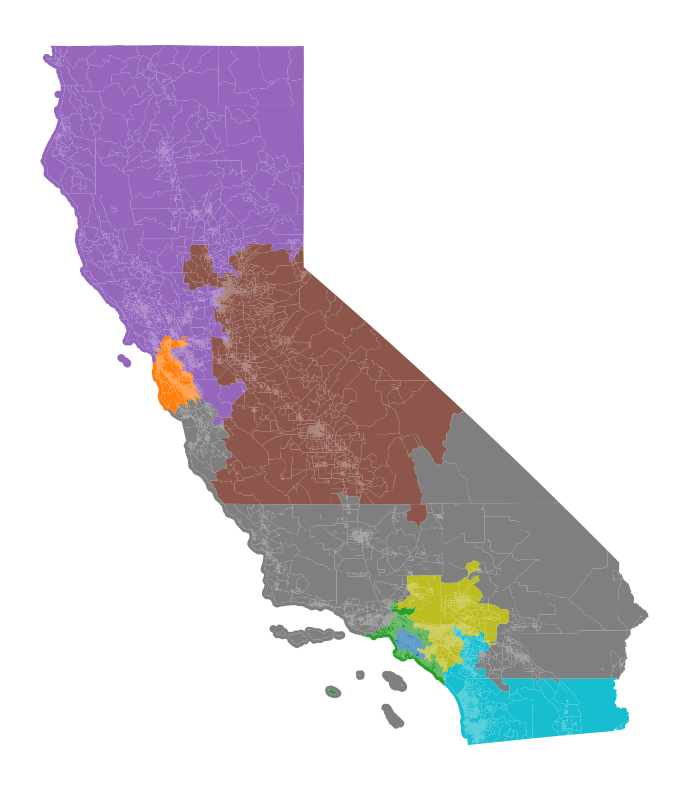

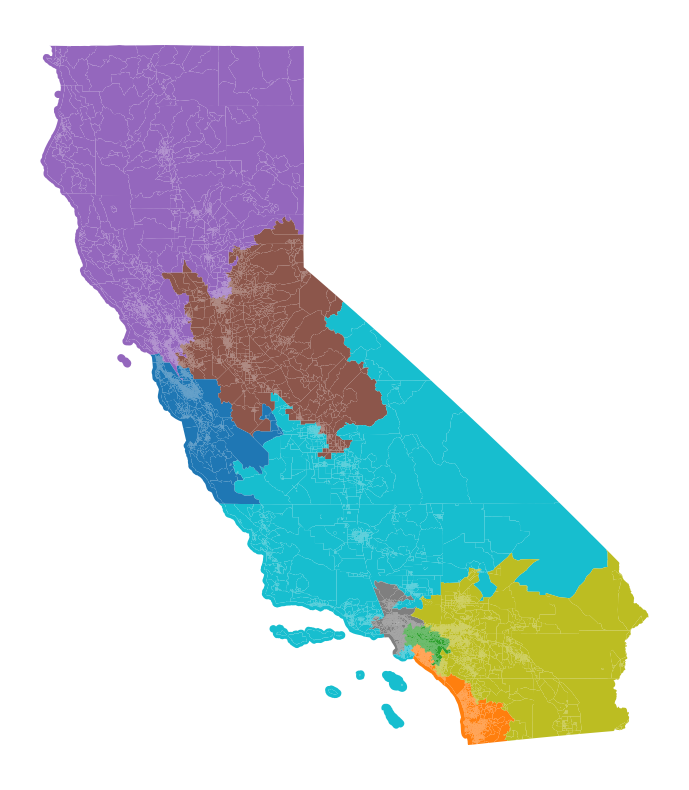

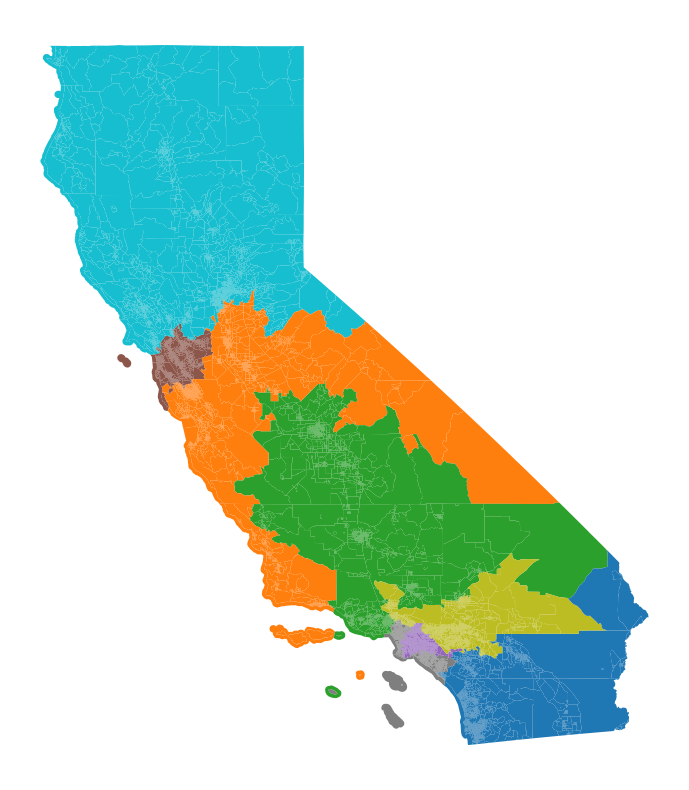

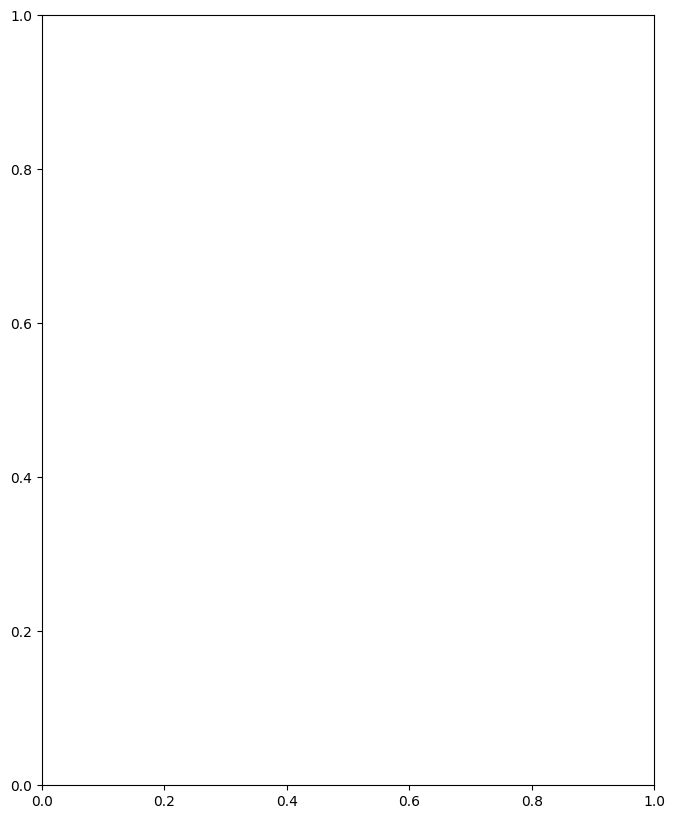

In [25]:
import json
from pathlib import Path
import jsonlines as jl
import pandas as pd

# Plots
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors

plan_directory = Path("chain_out/")
num_dist = [8, 10, 16, 20, 40, 80]

# Sampled iterations
plan_iter = [0, 200, 400, 600, 800]

# geo ID of block groups
BG_geoid_assignment = gdf["path"]

# For each district division
for n in num_dist:
    assignments = []
    filename = f"ca_{n}_dist.jsonl"

    # Extract each plan
    with open(plan_directory/filename, 'r') as file:
        for line in file:
            assignment = json.loads(line.strip())["assignment"]
            assignments.append(assignment) # Each entry is a plan, of a list
    
    # For each sampled plan
    for plan_n in plan_iter:

        # Save csv's of block group geoid matched with district assignment
        plan_assignment = assignments[plan_n]
        GEOID_assignment = pd.DataFrame({'GEOID': gdf["path"], 'assignment': plan_assignment})
        GEOID_assignment.to_csv(f'plan_geoid_assignments/ca_{n}_dist_plan_{plan_n}.csv', index=False)
    
        # Generate n distinct colors automatically
        # You can use any colormap, e.g., 'tab10', 'tab20', 'Set3', or 'viridis'
        cmap = plt.cm.get_cmap('tab10', n)
        colors_list = [mcolors.to_hex(cmap(i)) for i in range(n)]

        # Create dynamic color map dictionary
        color_map = dict(zip(range(n), colors_list))

        # Map each number to a color
        colors = [color_map[i] for i in plan_assignment]

        # Add to GeoDataFrame
        # gdf = gpd.read_file("your_file.shp")
        # Make sure it has same length as nums
        # gdf = gdf.iloc[:len(nums)].copy()
        gdf["color"] = colors

        # --- Plot ---
        fig, ax = plt.subplots(figsize=(15, 10))
        gdf.plot(color=gdf["color"], edgecolor=None, linewidth=0.1, ax=ax, legend=False)

        # --- Legend ---
        handles = [mpatches.Patch(color=c, label=f'Class {k}') for k, c in color_map.items()]
        #ax.legend(handles=handles, title="Classes", bbox_to_anchor=(1.05, 1))

        ax.set_axis_off()
        
        plt.savefig(f"plan_maps/ca_{n}_dist_plan_{plan_n}.png", dpi=300, bbox_inches="tight")



/var/folders/_6/vw90rr_n1k51nrvqcpj93ygr0000gn/T/ipykernel_10905/717689284.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', n)


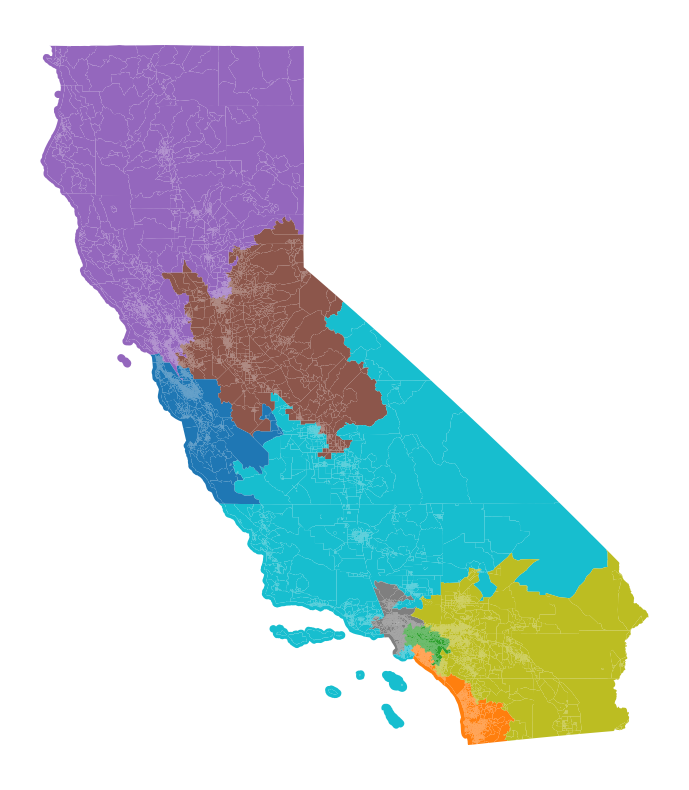

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors

n=8

# Generate n distinct colors automatically
# You can use any colormap, e.g., 'tab10', 'tab20', 'Set3', or 'viridis'
cmap = plt.cm.get_cmap('tab10', n)
colors_list = [mcolors.to_hex(cmap(i)) for i in range(n)]

# Create dynamic color map dictionary
color_map = dict(zip(range(n), colors_list))

# Map each number to a color
colors = [color_map[i] for i in sample_plan]

# Add to GeoDataFrame
# gdf = gpd.read_file("your_file.shp")
# Make sure it has same length as nums
# gdf = gdf.iloc[:len(nums)].copy()
gdf["color"] = colors

# --- Plot ---
fig, ax = plt.subplots(figsize=(15, 10))
gdf.plot(color=gdf["color"], edgecolor=None, linewidth=0.1, ax=ax, legend=False)

# --- Legend ---
handles = [mpatches.Patch(color=c, label=f'Class {k}') for k, c in color_map.items()]
#ax.legend(handles=handles, title="Classes", bbox_to_anchor=(1.05, 1))

ax.set_axis_off()
plt.show()